# Comparación de Trials que Cambiaron de Validez (Target Radius + 15%)

Este notebook compara lado a lado los 34 trials que cambiaron su estado de validez entre el análisis raw e interpolado.

**Modificación:** En las visualizaciones se usa `target_radius * 1.15` para analizar el efecto de aumentar el radio de aceptación en un 15%.

In [1]:
import sys
sys.path.insert(0, '/home/gianluca/Research/datapruebas_analysis')

from pathlib import Path
import pandas as pd

# Fechas de los análisis (con target_radius_multiplier = 1.1)
INTERPOLATED_DATE = "2026-01-26_09-43-18"
RAW_DATE =          "2026-01-26_09-29-28"

# Rutas
BASE_PATH = Path('/home/gianluca/Research/datapruebas_analysis/data/hand_analysis')
interp_path = BASE_PATH / INTERPOLATED_DATE / 'analysis.csv'
raw_path = BASE_PATH / RAW_DATE / 'analysis.csv'

In [2]:
# Cargar análisis completos (incluyendo trials inválidos)
df_interp = pd.read_csv(interp_path)
df_raw = pd.read_csv(raw_path)

print(f"Interpolado: {len(df_interp):,} trials ({df_interp['is_valid'].sum():,} válidos)")
print(f"Raw: {len(df_raw):,} trials ({df_raw['is_valid'].sum():,} válidos)")

Interpolado: 7,508 trials (5,851 válidos)
Raw: 7,508 trials (5,841 válidos)


In [3]:
# Merge para comparar lado a lado (incluir error_message para ver conteo real)
cols_to_compare = ['subject_id', 'trial_id', 'is_valid', 'invalid_cause', 'error_message', 'correct_targets_touches']

df_merged = pd.merge(
    df_raw[cols_to_compare],
    df_interp[cols_to_compare],
    on=['subject_id', 'trial_id'],
    suffixes=('_raw', '_interp')
)

# Filtrar trials donde cambió la validez
df_changed = df_merged[df_merged['is_valid_raw'] != df_merged['is_valid_interp']].copy()

print(f"Trials que cambiaron de validez: {len(df_changed)}")

Trials que cambiaron de validez: 12


In [4]:
# Extraer conteo de targets del error_message
import re

def extract_target_count(msg):
    if pd.isna(msg):
        return None
    match = re.search(r'has (\d+) correct target touches', str(msg))
    return int(match.group(1)) if match else None

df_changed['targets_raw'] = df_changed.apply(
    lambda r: int(r['correct_targets_touches_raw']) if r['is_valid_raw'] else extract_target_count(r['error_message_raw']),
    axis=1
)
df_changed['targets_interp'] = df_changed.apply(
    lambda r: int(r['correct_targets_touches_interp']) if r['is_valid_interp'] else extract_target_count(r['error_message_interp']),
    axis=1
)

# Ordenar: primero los que se volvieron válidos, luego por targets_raw
df_changed = df_changed.sort_values(['is_valid_interp', 'targets_raw'], ascending=[False, True])

# Mostrar tabla con columnas relevantes
df_changed[['subject_id', 'trial_id', 'is_valid_raw', 'targets_raw', 'is_valid_interp', 'targets_interp']]

,subject_id,trial_id,is_valid_raw,targets_raw,is_valid_interp,targets_interp
292,b1368f7d-47b5-45dd-83f4-5167eca84158,NEUROPRUEBAS_14,False,0,True,10
929,b4dc8afd-c6ae-4335-9694-217a9e6f2e05,NEUROPRUEBAS_5,False,0,True,10
1349,26815196-070f-4f94-a765-5bbecabea52c,NEUROPRUEBAS_10,False,0,True,10
3115,e2d6a929-32e1-4686-bbf3-06c53c6fa3d4,NEUROPRUEBAS_16,False,0,True,10
5043,3cf3fc83-1ee9-4389-9978-fa5845035019,NEUROPRUEBAS_18,False,0,True,10
5748,2d0c35d7-40cb-482e-9aef-46b729bd4275,NEUROPRUEBAS_21,False,0,True,10
6004,4d50dcc3-e333-4163-9894-058636a8e9c4,NEUROPRUEBAS_10,False,0,True,10
6299,2697d032-ba2c-45e4-8115-588455f5b491,NEUROPRUEBAS_5,False,0,True,10
6538,1300cad9-318b-45af-b103-7468573e1fb2,DATAPRUEBAS_10,False,2,True,10
3269,25ebf2c5-2a22-491a-b40e-03b62c8ce2ad,NEUROPRUEBAS_10,False,3,True,10


In [5]:
# Resumen de cambios en conteo de targets
raw_to_valid = df_changed[~df_changed['is_valid_raw'] & df_changed['is_valid_interp']]
valid_to_invalid = df_changed[df_changed['is_valid_raw'] & ~df_changed['is_valid_interp']]

print("=" * 60)
print(f"INVÁLIDO (raw) → VÁLIDO (interp): {len(raw_to_valid)} trials")
print("=" * 60)
print(f"{'targets_raw':<15} {'targets_interp':<15} {'cantidad':<10}")
print("-" * 40)
for targets_raw, group in raw_to_valid.groupby('targets_raw'):
    targets_interp = int(group['targets_interp'].iloc[0])
    print(f"{targets_raw:<15} {targets_interp:<15} {len(group):<10}")

print()
print("=" * 60)
print(f"VÁLIDO (raw) → INVÁLIDO (interp): {len(valid_to_invalid)} trials")
print("=" * 60)
print(f"{'targets_raw':<15} {'targets_interp':<15} {'cantidad':<10}")
print("-" * 40)
for targets_interp, group in valid_to_invalid.groupby('targets_interp'):
    targets_raw = int(group['targets_raw'].iloc[0])
    print(f"{targets_raw:<15} {targets_interp:<15} {len(group):<10}")

print()
print("=" * 60)
print(f"EFECTO NETO: {len(raw_to_valid) - len(valid_to_invalid):+d} trials")
print("=" * 60)

INVÁLIDO (raw) → VÁLIDO (interp): 11 trials
targets_raw     targets_interp  cantidad  
----------------------------------------
0               10              8         
2               10              1         
3               10              1         
8               10              1         

VÁLIDO (raw) → INVÁLIDO (interp): 1 trials
targets_raw     targets_interp  cantidad  
----------------------------------------
10              7               1         

EFECTO NETO: +10 trials


## Visualización de trials que cambiaron de Válido → Inválido

In [6]:
import matplotlib.pyplot as plt

# Trials que cambiaron de válido (raw) a inválido (interp)
valid_to_invalid = df_changed[df_changed['is_valid_raw'] & ~df_changed['is_valid_interp']]

print(f"Plotear {len(valid_to_invalid)} trials que pasaron de válido → inválido")
print(valid_to_invalid[['subject_id', 'trial_id', 'targets_raw', 'targets_interp']].to_string(index=False))

# Función para encontrar subject y trial en el experimento
def find_subject_and_trial(experiments, subject_id, trial_id):
    """Buscar subject y trial en los experimentos."""
    for exp in experiments:
        if subject_id in exp.subjects:
            subject = exp.subjects[subject_id]
            for trial in subject.testing_trials:
                if trial.id == trial_id:
                    return subject, trial
    return None, None

Plotear 1 trials que pasaron de válido → inválido
                          subject_id        trial_id  targets_raw  targets_interp
b35c298b-da71-4d41-a424-cdbc831da4fb NEUROPRUEBAS_18           10               7


In [7]:
from neurotask.tmt.metrics.distance_calculation import calculate_distance
from neurotask.tmt.model.tmt_model import TMTTrial

def calculate_min_distance_to_target(trial: TMTTrial, target_index: int) -> float:
    """
    Calcula la distancia mínima entre el cursor trail y un target específico.

    Args:
        trial: TMTTrial con cursor_trail y stimuli
        target_index: Índice del target en trial.stimuli (0-based)

    Returns:
        Distancia mínima en píxeles desde cualquier punto del cursor al centro del target
    """
    if target_index < 0 or target_index >= len(trial.stimuli):
        raise ValueError(f"target_index {target_index} fuera de rango (0-{len(trial.stimuli)-1})")

    target = trial.stimuli[target_index]
    cursor_trail = trial.get_cursor_trail_from_start()

    if not cursor_trail:
        return float('inf')

    min_dist = float('inf')
    for cursor_info in cursor_trail:
        dist = calculate_distance(cursor_info.position, target.position)
        min_dist = min(min_dist, dist)

    return min_dist


def identify_first_failed_target_index(targets_raw: int, targets_interp: int) -> int:
    """
    Identifica el índice (0-based) del primer target que falló en interpolado.

    Lógica:
    - Si raw=10, interp=6 → Primer fallo en índice 6 (el 7mo target)
    - Si raw=10, interp=0 → Primer fallo en índice 0 (el 1er target)

    Args:
        targets_raw: Número de targets tocados en raw (normalmente 10)
        targets_interp: Número de targets tocados en interpolado (< raw)

    Returns:
        Índice 0-based del primer target NO tocado en interpolado
    """
    return targets_interp


def analyze_trial_distance_change(
    subject_id: str,
    trial_id: str,
    trial_raw: TMTTrial,
    trial_interp: TMTTrial,
    targets_raw: int,
    targets_interp: int,
    base_target_radius: float
) -> dict:
    """
    Analiza un trial que cambió de válido a inválido.

    Args:
        subject_id: Identificador del sujeto
        trial_id: Identificador del trial
        trial_raw: TMTTrial de datos raw (sin interpolación)
        trial_interp: TMTTrial de datos interpolados
        targets_raw: Targets tocados en raw (debe ser 10)
        targets_interp: Targets tocados en interpolado (< 10)
        base_target_radius: Radio base (18px) antes del multiplicador

    Returns:
        Diccionario con resultados del análisis
    """
    # Identificar qué target falló
    failed_idx = identify_first_failed_target_index(targets_raw, targets_interp)

    # Obtener información del target
    target = trial_raw.stimuli[failed_idx]

    # Calcular distancias mínimas
    dist_raw = calculate_min_distance_to_target(trial_raw, failed_idx)
    dist_interp = calculate_min_distance_to_target(trial_interp, failed_idx)

    # Radio efectivo usado
    effective_radius = base_target_radius * 1.1

    return {
        'subject_id': subject_id,
        'trial_id': trial_id,
        'target_index': failed_idx,
        'target_number': failed_idx + 1,  # 1-based para legibilidad
        'target_content': target.content,
        'target_x': round(target.position.x, 1),
        'target_y': round(target.position.y, 1),
        'targets_raw': targets_raw,
        'targets_interp': targets_interp,
        'dist_raw': round(dist_raw, 4),
        'dist_interp': round(dist_interp, 4),
        'delta': round(dist_interp - dist_raw, 4),
        'base_radius': base_target_radius,
        'effective_radius': round(effective_radius, 2),
        'dist_raw_vs_radius': round(dist_raw - effective_radius, 4),
        'dist_interp_vs_radius': round(dist_interp - effective_radius, 4),
    }

## Comparación lado a lado: Raw vs Interpolado

In [8]:
from src import config
from importlib import reload

# Cargar SIN interpolación
config.INTERPOLATE_TRAJECTORY = False
import src.visualization.plot_trials_cli as plot_cli
reload(plot_cli)
exp_raw_dp = plot_cli.load_experiment("datapruebas")
exp_raw_np = plot_cli.load_experiment("neuropruebas")

print(f"Raw - Datapruebas: {len(exp_raw_dp.subjects)} sujetos")
print(f"Raw - Neuropruebas: {len(exp_raw_np.subjects)} sujetos")

Mapping 127 subjects...


ERROR:root:Error processing experiment for subject f7031def-b705-41e7-aa54-da7e0c4ee601
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 94, in map_to_subject
    raise ValueError("Subject must have both training and testing stimuli")
ValueError: Subject must have both training and testing stimuli
ERROR:root:Error processing experiment for subject c890dfc5-aea9-4f93-833e-988009c44d71
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gianluca/Research/dataprueb

Mapped 58 valid subjects.


ERROR:root:Error processing experiment for subject b7701e5e-85c1-43d1-8617-ab4944c95d48
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 145, in map_to_experiment
    subjects[subject_id] = self.map_to_subject(subject_id, subject_data, session_data)
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 234, in map_to_subject
    testing_trials, training_trials = self.map_to_testing_training_trials(subject_data, testing_stimuli,
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 254, in map_to_testing_training_trials
    self._extract_position_and_time_data(subject_data, training_stimuli, testing_stimuli))
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 283, in _extract_position_and_time_data
    raise ValueError("Subject csv does

Raw - Datapruebas: 58 sujetos
Raw - Neuropruebas: 355 sujetos


In [9]:
# Cargar CON interpolación
config.INTERPOLATE_TRAJECTORY = True
reload(plot_cli)
exp_interp_dp = plot_cli.load_experiment("datapruebas")
exp_interp_np = plot_cli.load_experiment("neuropruebas")

print(f"Interp - Datapruebas: {len(exp_interp_dp.subjects)} sujetos")
print(f"Interp - Neuropruebas: {len(exp_interp_np.subjects)} sujetos")

ERROR:root:Error processing experiment for subject f7031def-b705-41e7-aa54-da7e0c4ee601
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 94, in map_to_subject
    raise ValueError("Subject must have both training and testing stimuli")
ValueError: Subject must have both training and testing stimuli
ERROR:root:Error processing experiment for subject c890dfc5-aea9-4f93-833e-988009c44d71
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gianluca/Research/dataprueb

Mapping 127 subjects...


ERROR:root:Error processing experiment for subject 139efc97-c335-401c-a98f-dd3825ab2d87
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 94, in map_to_subject
    raise ValueError("Subject must have both training and testing stimuli")
ValueError: Subject must have both training and testing stimuli
ERROR:root:Error processing experiment for subject d93d5b6d-7206-429f-80d0-3bb78b461c5b
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gianluca/Research/dataprueb

Mapped 58 valid subjects.


ERROR:root:Error processing experiment for subject b7701e5e-85c1-43d1-8617-ab4944c95d48
Traceback (most recent call last):
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 145, in map_to_experiment
    subjects[subject_id] = self.map_to_subject(subject_id, subject_data, session_data)
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 234, in map_to_subject
    testing_trials, training_trials = self.map_to_testing_training_trials(subject_data, testing_stimuli,
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 254, in map_to_testing_training_trials
    self._extract_position_and_time_data(subject_data, training_stimuli, testing_stimuli))
  File "/home/gianluca/Research/datapruebas_analysis/src/mapper/neuropruebas/neuropruebas_mapper.py", line 283, in _extract_position_and_time_data
    raise ValueError("Subject csv does

Interp - Datapruebas: 58 sujetos
Interp - Neuropruebas: 355 sujetos


In [ ]:
from src.visualization.trial_plotting_labels import plot_trial_simple

# Plot comparativo lado a lado
fig, axes = plt.subplots(10, 2, figsize=(12, 40))

for idx, (_, row) in enumerate(valid_to_invalid.iterrows()):
    subject_id = row['subject_id']
    trial_id = row['trial_id']
    targets_raw = row['targets_raw']
    targets_interp = row['targets_interp']
    
    # Buscar en raw
    subj_raw, trial_raw = find_subject_and_trial([exp_raw_dp, exp_raw_np], subject_id, trial_id)
    # Buscar en interpolado
    subj_interp, trial_interp = find_subject_and_trial([exp_interp_dp, exp_interp_np], subject_id, trial_id)
    
    # Plot raw (izquierda)
    plot_trial_simple(axes[idx, 0], trial_raw, subj_raw.target_radius, f"RAW - {trial_id}\ntargets: {targets_raw}", show_line=False)
    
    # Plot interpolado (derecha)
    plot_trial_simple(axes[idx, 1], trial_interp, subj_interp.target_radius, f"INTERP - {trial_id}\ntargets: {targets_interp}", show_line=False)

plt.suptitle("Comparación: Raw (izq) vs Interpolado (der)", fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

In [11]:
# Verificar target_radius de todos los trials en df_changed
target_radii = []

for _, row in df_changed.iterrows():
    subject_id = row['subject_id']
    trial_id = row['trial_id']
    
    # Buscar en raw
    subj_raw, trial_raw = find_subject_and_trial([exp_raw_dp, exp_raw_np], subject_id, trial_id)
    
    if subj_raw:
        target_radii.append({
            'subject_id': subject_id,
            'trial_id': trial_id,
            'target_radius': subj_raw.target_radius
        })

df_radii = pd.DataFrame(target_radii)

print("=" * 60)
print("ANÁLISIS DE TARGET_RADIUS")
print("=" * 60)
print(f"Total trials analizados: {len(df_radii)}")
print(f"\nValores únicos de target_radius:")
print(df_radii['target_radius'].value_counts().sort_index())
print(f"\nEstadísticas:")
print(df_radii['target_radius'].describe())
print(f"\n¿Son todos iguales? {df_radii['target_radius'].nunique() == 1}")
if df_radii['target_radius'].nunique() == 1:
    print(f"Valor común: {df_radii['target_radius'].iloc[0]} px")

ANÁLISIS DE TARGET_RADIUS
Total trials analizados: 12

Valores únicos de target_radius:
target_radius
18.0    12
Name: count, dtype: int64

Estadísticas:
count    12.0
mean     18.0
std       0.0
min      18.0
25%      18.0
50%      18.0
75%      18.0
max      18.0
Name: target_radius, dtype: float64

¿Son todos iguales? True
Valor común: 18.0 px


In [12]:
# Analizar todos los trials válido→inválido
results = []

print(f"Analizando {len(valid_to_invalid)} trials que pasaron de válido → inválido...")

for _, row in valid_to_invalid.iterrows():
    subject_id = row['subject_id']
    trial_id = row['trial_id']
    targets_raw = row['targets_raw']
    targets_interp = row['targets_interp']

    # Buscar trials en experimentos cargados
    subj_raw, trial_raw = find_subject_and_trial([exp_raw_dp, exp_raw_np], subject_id, trial_id)
    subj_interp, trial_interp = find_subject_and_trial([exp_interp_dp, exp_interp_np], subject_id, trial_id)

    if trial_raw is None or trial_interp is None:
        print(f"⚠️  No se encontró trial {trial_id} para subject {subject_id}")
        continue

    # Analizar este trial
    result = analyze_trial_distance_change(
        subject_id=subject_id,
        trial_id=trial_id,
        trial_raw=trial_raw,
        trial_interp=trial_interp,
        targets_raw=targets_raw,
        targets_interp=targets_interp,
        base_target_radius=subj_raw.target_radius / 1.1  # Revertir multiplicador para obtener base
    )

    results.append(result)

# Crear DataFrame con resultados
df_analysis = pd.DataFrame(results)

print(f"✓ Análisis completado: {len(df_analysis)} trials procesados")

Analizando 1 trials que pasaron de válido → inválido...
✓ Análisis completado: 1 trials procesados


In [13]:
# Mostrar tabla de resultados
print("\n" + "=" * 100)
print(f"ANÁLISIS DE DISTANCIAS: {len(df_analysis)} trials válido → inválido")
print("=" * 100)

print("\n📊 EXPLICACIÓN DE COLUMNAS:")
print("  • target_number: Número del primer target que falló (1-10)")
print("  • target_content: Contenido mostrado en el target (ej: '7', 'D')")
print("  • dist_raw: Distancia mínima cursor→target en RAW (píxeles)")
print("  • dist_interp: Distancia mínima cursor→target en INTERPOLADO (píxeles)")
print("  • delta: dist_interp - dist_raw (positivo = más lejos en interp)")
print("  • effective_radius: 19.8px (18px base * 1.1)")
print("  • dist_*_vs_radius: Distancia vs radio (negativo = dentro, positivo = fuera)\n")

# Seleccionar columnas para mostrar
display_cols = [
    'subject_id', 'trial_id', 'target_number', 'target_content',
    'dist_raw', 'dist_interp', 'delta',
    'dist_raw_vs_radius', 'dist_interp_vs_radius'
]

print(df_analysis[display_cols].to_string(index=False))

# Estadísticas resumidas
print("\n" + "=" * 100)
print("📈 ESTADÍSTICAS RESUMIDAS")
print("=" * 100)

print(f"\n🔹 Cambio de distancia (delta):")
print(f"   Promedio: {df_analysis['delta'].mean():>7.2f} px")
print(f"   Mediana:  {df_analysis['delta'].median():>7.2f} px")
print(f"   Mínimo:   {df_analysis['delta'].min():>7.2f} px")
print(f"   Máximo:   {df_analysis['delta'].max():>7.2f} px")

print(f"\n🔹 Trials donde RAW estaba DENTRO del radio:")
inside_raw = (df_analysis['dist_raw_vs_radius'] < 0).sum()
print(f"   {inside_raw} de {len(df_analysis)} trials ({inside_raw/len(df_analysis)*100:.1f}%)")

print(f"\n🔹 Trials donde INTERPOLADO está FUERA del radio:")
outside_interp = (df_analysis['dist_interp_vs_radius'] > 0).sum()
print(f"   {outside_interp} de {len(df_analysis)} trials ({outside_interp/len(df_analysis)*100:.1f}%)")

print(f"\n🔹 Distribución de targets fallidos:")
target_dist = df_analysis['target_number'].value_counts().sort_index()
for target_num, count in target_dist.items():
    print(f"   Target #{target_num}: {count} trial(s)")


ANÁLISIS DE DISTANCIAS: 1 trials válido → inválido

📊 EXPLICACIÓN DE COLUMNAS:
  • target_number: Número del primer target que falló (1-10)
  • target_content: Contenido mostrado en el target (ej: '7', 'D')
  • dist_raw: Distancia mínima cursor→target en RAW (píxeles)
  • dist_interp: Distancia mínima cursor→target en INTERPOLADO (píxeles)
  • delta: dist_interp - dist_raw (positivo = más lejos en interp)
  • effective_radius: 19.8px (18px base * 1.1)
  • dist_*_vs_radius: Distancia vs radio (negativo = dentro, positivo = fuera)

                          subject_id        trial_id  target_number target_content  dist_raw  dist_interp  delta  dist_raw_vs_radius  dist_interp_vs_radius
b35c298b-da71-4d41-a424-cdbc831da4fb NEUROPRUEBAS_18              8              8   20.6069       21.123 0.5162              2.6069                  3.123

📈 ESTADÍSTICAS RESUMIDAS

🔹 Cambio de distancia (delta):
   Promedio:    0.52 px
   Mediana:     0.52 px
   Mínimo:      0.52 px
   Máximo:      0.52 

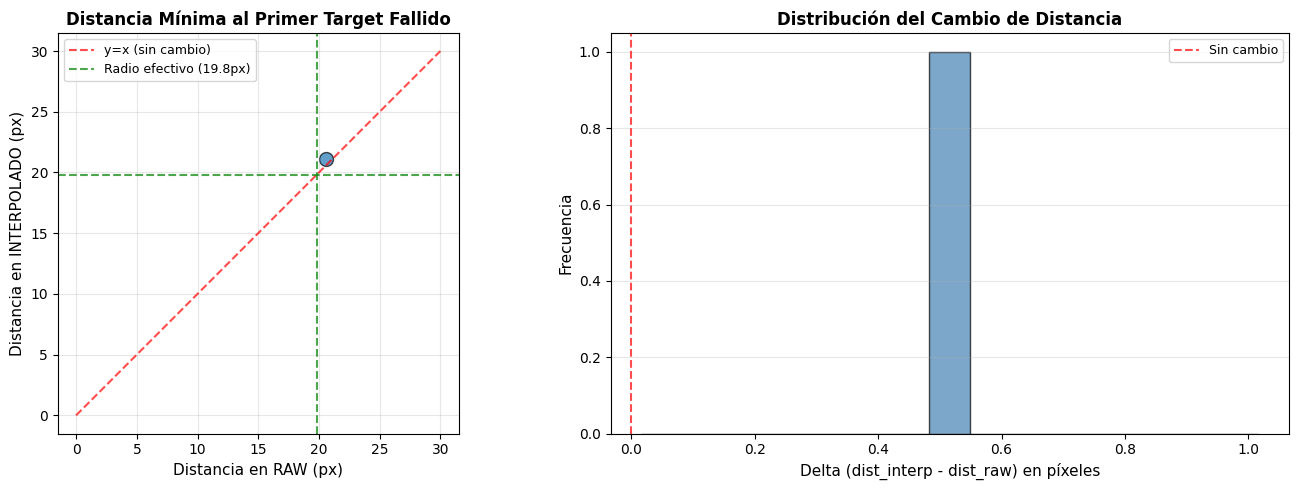

In [14]:
# Visualizaciones gráficas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scatter dist_raw vs dist_interp
ax1 = axes[0]
ax1.scatter(df_analysis['dist_raw'], df_analysis['dist_interp'], alpha=0.7, s=100, edgecolor='black')
ax1.plot([0, 30], [0, 30], 'r--', linewidth=1.5, label='y=x (sin cambio)', alpha=0.7)
ax1.axhline(y=19.8, color='green', linestyle='--', linewidth=1.5, label='Radio efectivo (19.8px)', alpha=0.7)
ax1.axvline(x=19.8, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Distancia en RAW (px)', fontsize=11)
ax1.set_ylabel('Distancia en INTERPOLADO (px)', fontsize=11)
ax1.set_title('Distancia Mínima al Primer Target Fallido', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Gráfico 2: Histograma de delta
ax2 = axes[1]
ax2.hist(df_analysis['delta'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Sin cambio', alpha=0.7)
ax2.set_xlabel('Delta (dist_interp - dist_raw) en píxeles', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución del Cambio de Distancia', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [15]:
# Calcular multiplicador mínimo necesario para evitar todos los fallos
print("\n" + "=" * 100)
print("🎯 CÁLCULO DEL MULTIPLICADOR MÍNIMO NECESARIO")
print("=" * 100)

# Distancia máxima en interpolado
max_dist_interp = df_analysis['dist_interp'].max()
base_radius = df_analysis['base_radius'].iloc[0]

# Calcular multiplicador mínimo
min_multiplier = max_dist_interp / base_radius
min_increase_pct = (min_multiplier - 1) * 100

print(f"\n📏 Radio base: {base_radius} px")
print(f"📏 Radio actual (con 1.1x): {base_radius * 1.1:.1f} px")
print(f"📏 Distancia interpolada máxima: {max_dist_interp:.4f} px")

print(f"\n🎯 Multiplicador mínimo necesario: {min_multiplier:.4f}")
print(f"🎯 Aumento mínimo necesario: {min_increase_pct:.2f}%")

print(f"\n💡 Para que NINGÚN trial pase de válido → inválido:")
print(f"   - Radio necesario: {max_dist_interp:.4f} px")
print(f"   - Multiplicador: {min_multiplier:.4f} (en lugar de 1.1)")
print(f"   - Aumento: {min_increase_pct:.2f}% (en lugar de 10%)")

# Mostrar cuántos trials quedarían dentro con diferentes multiplicadores
print(f"\n📊 ANÁLISIS DE COBERTURA:")
multipliers = [1.1, 1.12, 1.13, min_multiplier, 1.15]
for mult in multipliers:
    radius = base_radius * mult
    inside = (df_analysis['dist_interp'] <= radius).sum()
    pct = inside / len(df_analysis) * 100
    print(f"   Radio {radius:.2f}px (×{mult:.2f}): {inside}/{len(df_analysis)} trials válidos ({pct:.0f}%)")


🎯 CÁLCULO DEL MULTIPLICADOR MÍNIMO NECESARIO

📏 Radio base: 16.363636363636363 px
📏 Radio actual (con 1.1x): 18.0 px
📏 Distancia interpolada máxima: 21.1230 px

🎯 Multiplicador mínimo necesario: 1.2909
🎯 Aumento mínimo necesario: 29.09%

💡 Para que NINGÚN trial pase de válido → inválido:
   - Radio necesario: 21.1230 px
   - Multiplicador: 1.2909 (en lugar de 1.1)
   - Aumento: 29.09% (en lugar de 10%)

📊 ANÁLISIS DE COBERTURA:
   Radio 18.00px (×1.10): 0/1 trials válidos (0%)
   Radio 18.33px (×1.12): 0/1 trials válidos (0%)
   Radio 18.49px (×1.13): 0/1 trials válidos (0%)
   Radio 21.12px (×1.29): 1/1 trials válidos (100%)
   Radio 18.82px (×1.15): 0/1 trials válidos (0%)


## Trials que pasaron de Inválido → Válido 

Plotear 11 trials que pasaron de inválido → válido


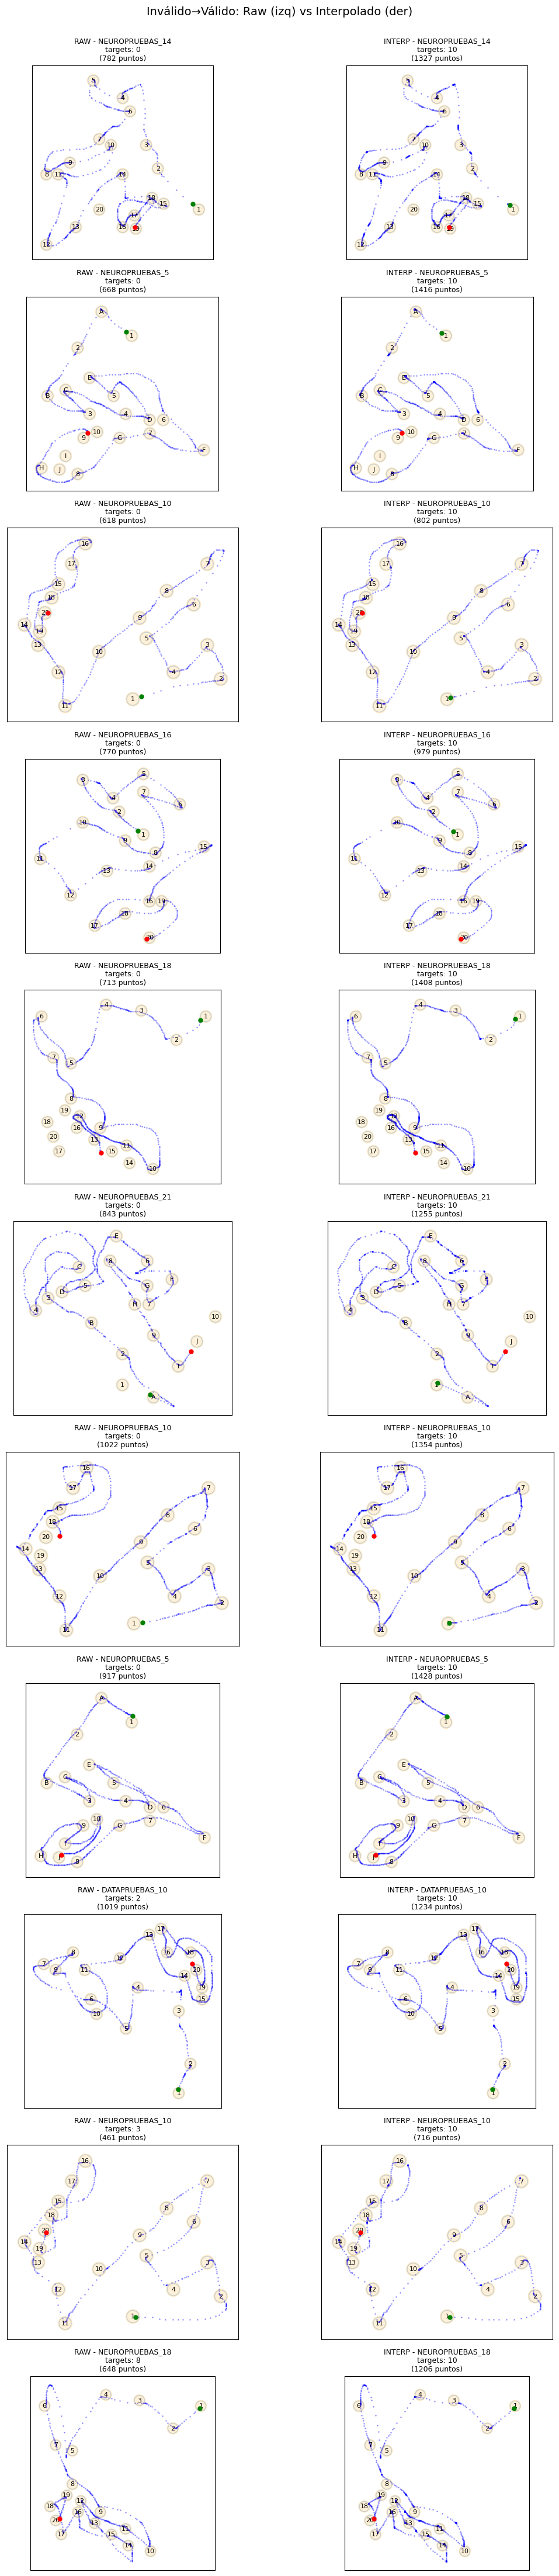

In [26]:
from importlib import reload
from src.visualization import trial_plotting_helpers, trial_plotting_labels
reload(trial_plotting_helpers)
reload(trial_plotting_labels)
from src.visualization.trial_plotting_labels import plot_trial_simple


# Trials que cambiaron de inválido (raw) a válido (interp)
invalid_to_valid = df_changed[~df_changed['is_valid_raw'] & df_changed['is_valid_interp']]

print(f"Plotear {len(invalid_to_valid)} trials que pasaron de inválido → válido")

# Plot comparativo lado a lado
fig, axes = plt.subplots(len(invalid_to_valid), 2, figsize=(12, 4 * len(invalid_to_valid)))

for idx, (_, row) in enumerate(invalid_to_valid.iterrows()):
    subject_id = row['subject_id']
    trial_id = row['trial_id']
    targets_raw = row['targets_raw']
    targets_interp = row['targets_interp']
    
    # Buscar en raw
    subj_raw, trial_raw = find_subject_and_trial([exp_raw_dp, exp_raw_np], subject_id, trial_id)
    # Buscar en interpolado
    subj_interp, trial_interp = find_subject_and_trial([exp_interp_dp, exp_interp_np], subject_id, trial_id)
    
    # Plot raw (izquierda)
    plot_trial_simple(axes[idx, 0], trial_raw, subj_raw.target_radius, f"RAW - {trial_id}\ntargets: {targets_raw}", show_line=False,
                      radius_multiplier=1.15)
    
    # Plot interpolado (derecha)
    plot_trial_simple(axes[idx, 1], trial_interp, subj_interp.target_radius, f"INTERP - {trial_id}\ntargets: {targets_interp}", show_line=False,
                      radius_multiplier=1.15)

plt.suptitle("Inválido→Válido: Raw (izq) vs Interpolado (der)", fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

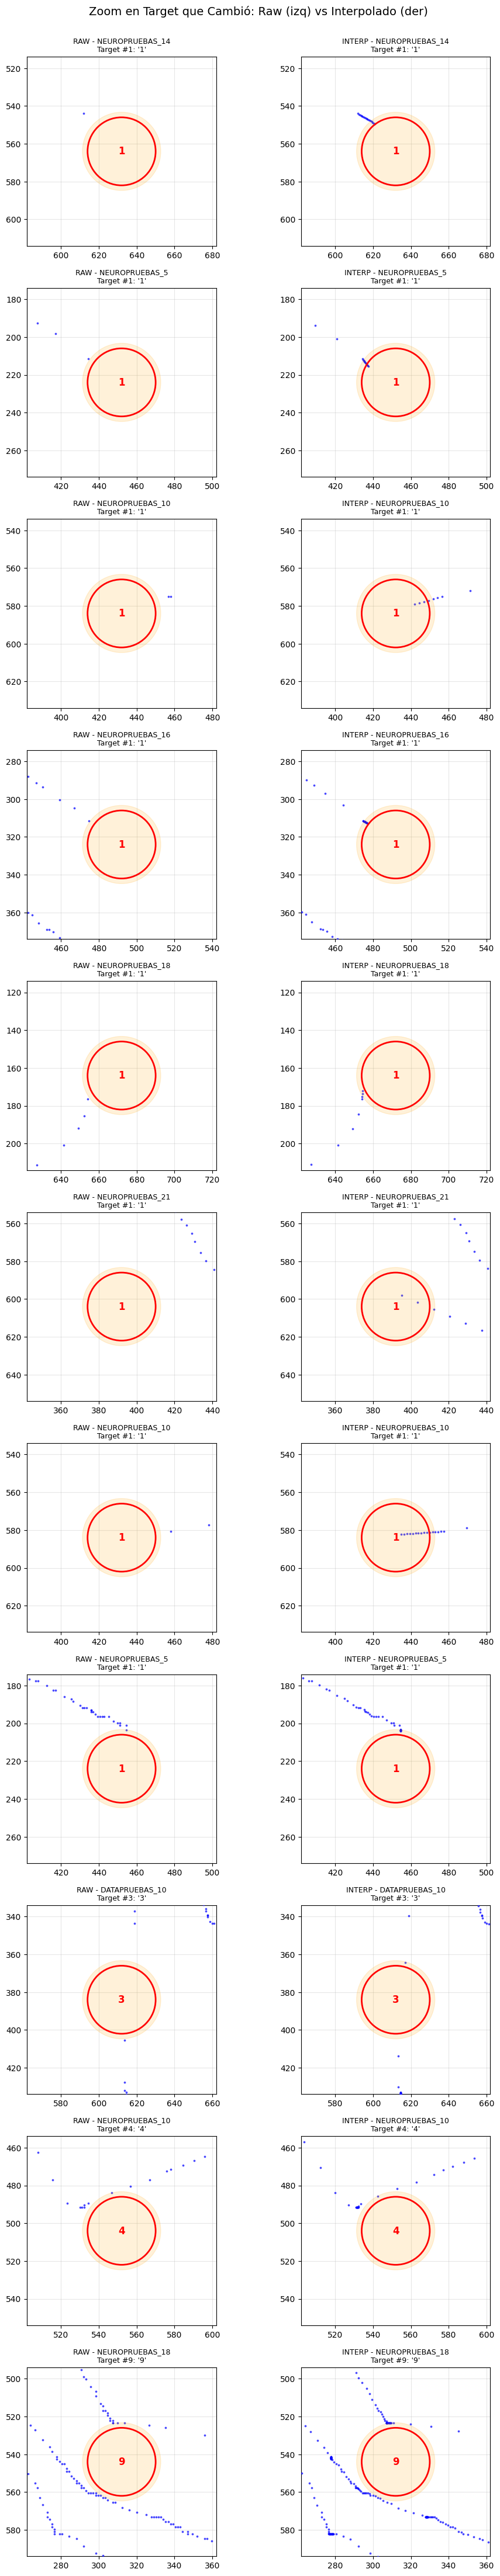

In [28]:
# Zoom en el target que cambió para cada trial inválido → válido
from src.visualization.trial_plotting_helpers import draw_trial_trajectory

def plot_target_zoom(ax, trial, target_radius, target_idx, title, show_line=False, margin=50, radius_multiplier=1.15):
    """Plot con zoom en un target específico."""
    if trial is None or target_idx >= len(trial.stimuli):
        ax.set_title(f"{title}\nNo encontrado")
        ax.axis('off')
        return
    
    target = trial.stimuli[target_idx]
    tx, ty = target.position.x, target.position.y
    
    # Extraer coordenadas del cursor
    cursor_trail = trial.get_cursor_trail_from_start()
    x = [c.position.x for c in cursor_trail]
    y = [c.position.y for c in cursor_trail]
    
    # Dibujar trayectoria
    draw_trial_trajectory(ax, x, y, show_line=show_line, scatter_size=3, scatter_alpha=0.6)
    
    # Dibujar sombra del radio efectivo (naranja)
    if radius_multiplier and radius_multiplier != 1.0:
        effective_radius = target_radius * radius_multiplier
        shadow = plt.Circle((tx, ty), effective_radius, fill=True, color='orange', alpha=0.15, zorder=4)
        ax.add_patch(shadow)
    
    # Dibujar el target (rojo)
    circle = plt.Circle((tx, ty), target_radius, fill=False, color='red', linewidth=2, zorder=5)
    ax.add_patch(circle)
    ax.text(tx, ty, target.content, color='red', fontsize=12, ha='center', va='center', fontweight='bold', zorder=6)
    
    # Zoom centrado en el target
    ax.set_xlim(tx - margin, tx + margin)
    ax.set_ylim(ty + margin, ty - margin)  # Invertido para coordenadas de pantalla
    ax.set_aspect('equal')
    ax.set_title(f"{title}\nTarget #{target_idx+1}: '{target.content}'", fontsize=9)
    ax.grid(True, alpha=0.3)

# Plot con zoom en el target que cambió
n_trials = len(invalid_to_valid)
fig, axes = plt.subplots(n_trials, 2, figsize=(10, 4 * n_trials))

# Asegurar que axes sea 2D incluso con 1 trial
if n_trials == 1:
    axes = axes.reshape(1, -1)

for idx, (_, row) in enumerate(invalid_to_valid.iterrows()):
    subject_id = row['subject_id']
    trial_id = row['trial_id']
    targets_raw = row['targets_raw']
    
    # El target que cambió es el primero que falló en raw (índice = targets_raw)
    target_idx = targets_raw
    
    # Buscar trials
    subj_raw, trial_raw = find_subject_and_trial([exp_raw_dp, exp_raw_np], subject_id, trial_id)
    subj_interp, trial_interp = find_subject_and_trial([exp_interp_dp, exp_interp_np], subject_id, trial_id)
    
    # Plot zoom raw (izquierda)
    plot_target_zoom(axes[idx, 0], trial_raw, subj_raw.target_radius, target_idx, 
                     f"RAW - {trial_id}", show_line=False, radius_multiplier=1.15)
    
    # Plot zoom interpolado (derecha)
    plot_target_zoom(axes[idx, 1], trial_interp, subj_interp.target_radius, target_idx,
                     f"INTERP - {trial_id}", show_line=False, radius_multiplier=1.15)

plt.suptitle("Zoom en Target que Cambió: Raw (izq) vs Interpolado (der)", fontsize=14, y=1.001)
plt.tight_layout()
plt.show()